<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv
Dataset loaded successfully!
Dataset Shape: (50000, 32)

First 5 Rows:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Specialisation      50000 non-null  object 
 6   Hostel              50000 non-null  object 
 7   HistoryOfBacklogs   50000 non-null  object 
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-n

,Criterion,Train Accuracy,Test Accuracy,Depth,Leaves
0,Gini,1.0,0.8725,33,2888
1,Entropy,1.0,0.8768,35,2664



DEPTH SWEEP


,Depth,Train Accuracy,Test Accuracy
0,1,0.8421,0.8393
1,2,0.8672,0.8655
2,3,0.8832,0.8797
3,4,0.8939,0.8878
4,5,0.9040,0.8974
5,6,0.9080,0.9003
6,7,0.9129,0.9042
7,8,0.9161,0.9036
8,9,0.9212,0.9059
9,10,0.9275,0.9001


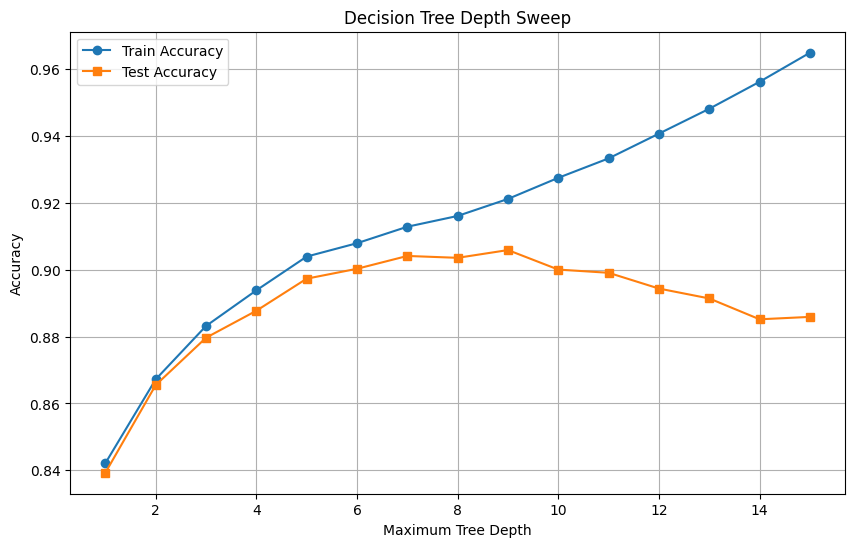

Best Depth: 9
Best Test Accuracy: 0.9059

COST-COMPLEXITY PRUNING
Number of CCP Alpha Values: 1302

First 10 CCP Alpha Values:
[0.00000000e+00 1.33176839e-05 1.33319928e-05 1.68421053e-05
 1.71647510e-05 1.72222222e-05 1.72222222e-05 1.73441734e-05
 1.73827160e-05 1.73913043e-05]


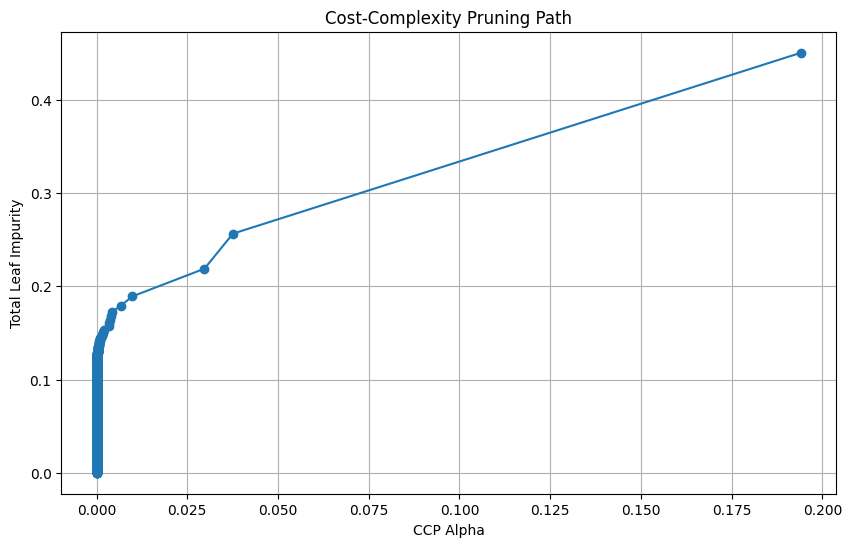

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())


print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


F = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

target = "PlacementStatus"

missing_columns = [col for col in F + [target] if col not in df.columns]

if missing_columns:
    print("\nMissing columns:", missing_columns)
    raise ValueError(
        "Some required columns are not present in the dataset."
    )


X = df[F].copy()
y = df[target].copy()

X = X.fillna(X.median(numeric_only=True))

print("\nFeatures Used:")
print(F)

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)


print("\nPlacement Status Distribution:")
print(y.value_counts())

print("\nPlacement Status Percentage:")
print((y.value_counts(normalize=True) * 100).round(2))


Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", Xtr.shape[0])
print("Testing Samples :", Xte.shape[0])


print("\n" + "=" * 60)
print("GINI DECISION TREE")
print("=" * 60)

gini_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=0
)

gini_tree.fit(Xtr, ytr)

gini_train = gini_tree.score(Xtr, ytr)
gini_test = gini_tree.score(Xte, yte)

print("Training Accuracy :", round(gini_train, 4))
print("Testing Accuracy  :", round(gini_test, 4))
print("Tree Depth         :", gini_tree.get_depth())
print("Number of Leaves   :", gini_tree.get_n_leaves())


print("\n" + "=" * 60)
print("ENTROPY DECISION TREE")
print("=" * 60)

entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

entropy_tree.fit(Xtr, ytr)

entropy_train = entropy_tree.score(Xtr, ytr)
entropy_test = entropy_tree.score(Xte, yte)

print("Training Accuracy :", round(entropy_train, 4))
print("Testing Accuracy  :", round(entropy_test, 4))
print("Tree Depth         :", entropy_tree.get_depth())
print("Number of Leaves   :", entropy_tree.get_n_leaves())


comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Train Accuracy": [gini_train, entropy_train],
    "Test Accuracy": [gini_test, entropy_test],
    "Depth": [
        gini_tree.get_depth(),
        entropy_tree.get_depth()
    ],
    "Leaves": [
        gini_tree.get_n_leaves(),
        entropy_tree.get_n_leaves()
    ]
})

print("\nGINI VS ENTROPY COMPARISON:")
display(comparison.round(4))


print("\n" + "=" * 60)
print("DEPTH SWEEP")
print("=" * 60)

depths = range(1, 16)

train_accuracy = []
test_accuracy = []

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=0
    )

    tree.fit(Xtr, ytr)

    train_accuracy.append(
        tree.score(Xtr, ytr)
    )

    test_accuracy.append(
        tree.score(Xte, yte)
    )

depth_results = pd.DataFrame({
    "Depth": list(depths),
    "Train Accuracy": train_accuracy,
    "Test Accuracy": test_accuracy
})

display(depth_results.round(4))


plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_accuracy,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    depths,
    test_accuracy,
    marker="s",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth Sweep")
plt.legend()
plt.grid(True)
plt.show()


best_depth_index = np.argmax(test_accuracy)
best_depth = list(depths)[best_depth_index]
best_depth_accuracy = test_accuracy[best_depth_index]

print("Best Depth:", best_depth)
print("Best Test Accuracy:", round(best_depth_accuracy, 4))


print("\n" + "=" * 60)
print("COST-COMPLEXITY PRUNING")
print("=" * 60)

# Train full tree
full_tree = DecisionTreeClassifier(
    random_state=0
)

full_tree.fit(Xtr, ytr)

# Obtain CCP pruning path
path = full_tree.cost_complexity_pruning_path(
    Xtr,
    ytr
)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of CCP Alpha Values:", len(ccp_alphas))

print("\nFirst 10 CCP Alpha Values:")
print(ccp_alphas[:10])


plt.figure(figsize=(10, 6))

plt.plot(
    ccp_alphas,
    impurities,
    marker="o"
)

plt.xlabel("CCP Alpha")
plt.ylabel("Total Leaf Impurity")
plt.title("Cost-Complexity Pruning Path")
plt.grid(True)
plt.show()


cv_scores = []

for alpha in ccp_alphas:

    tree = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=0
    )

    scores = cross_val_score(
        tree,
        Xtr,
        ytr,
        cv=5
    )

    cv_scores.append(scores.mean())

best_index = np.argmax(cv_scores)
best_alpha = ccp_alphas[best_index]

print("\nBest CCP Alpha:", best_alpha)
print(
    "Best Cross-Validation Accuracy:",
    round(cv_scores[best_index], 4)
)


plt.figure(figsize=(10, 6))

plt.plot(
    ccp_alphas,
    cv_scores,
    marker="o"
)

plt.axvline(
    best_alpha,
    linestyle="--",
    label=f"Best Alpha = {best_alpha:.5f}"
)

plt.xlabel("CCP Alpha")
plt.ylabel("Cross-Validation Accuracy")
plt.title("CCP Alpha vs Cross-Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


print("\n" + "=" * 60)
print("PRUNED DECISION TREE")
print("=" * 60)

pruned_tree = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=0
)

pruned_tree.fit(Xtr, ytr)

pruned_train = pruned_tree.score(Xtr, ytr)
pruned_test = pruned_tree.score(Xte, yte)

print("Best CCP Alpha :", best_alpha)
print("Train Accuracy :", round(pruned_train, 4))
print("Test Accuracy  :", round(pruned_test, 4))
print("Tree Depth     :", pruned_tree.get_depth())
print("Number Leaves  :", pruned_tree.get_n_leaves())


tree_comparison = pd.DataFrame({
    "Model": [
        "Full Tree",
        "Pruned Tree"
    ],

    "Train Accuracy": [
        full_tree.score(Xtr, ytr),
        pruned_tree.score(Xtr, ytr)
    ],

    "Test Accuracy": [
        full_tree.score(Xte, yte),
        pruned_tree.score(Xte, yte)
    ],

    "Depth": [
        full_tree.get_depth(),
        pruned_tree.get_depth()
    ],

    "Leaves": [
        full_tree.get_n_leaves(),
        pruned_tree.get_n_leaves()
    ]
})

print("\nFULL TREE VS PRUNED TREE:")
display(tree_comparison.round(4))


print("\n" + "=" * 60)
print("PRUNED TREE VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(22, 12))

plot_tree(
    pruned_tree,
    feature_names=F,
    class_names=["Not Placed", "Placed"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Pruned Decision Tree")
plt.show()


print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

importance = pd.Series(
    pruned_tree.feature_importances_,
    index=F
).sort_values(ascending=False)

print("Feature Importance:")
display(
    importance.round(4).to_frame("Importance")
)


plt.figure(figsize=(10, 7))

importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.grid(True)
plt.show()


print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

y_pred = pruned_tree.predict(Xte)

cm = confusion_matrix(
    yte,
    y_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Pruned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.yticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()


print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        yte,
        y_pred,
        target_names=[
            "Not Placed",
            "Placed"
        ]
    )
)


print("\n" + "=" * 60)
print("DECISION RULES")
print("=" * 60)

rules = export_text(
    pruned_tree,
    feature_names=F
)

print(rules)



print("\n" + "=" * 60)
print("FINAL EXPERIMENT 6 SUMMARY")
print("=" * 60)

final_results = pd.DataFrame({

    "Model": [
        "Gini Tree",
        "Entropy Tree",
        "Full Tree",
        "Pruned Tree"
    ],

    "Train Accuracy": [
        gini_train,
        entropy_train,
        full_tree.score(Xtr, ytr),
        pruned_tree.score(Xtr, ytr)
    ],

    "Test Accuracy": [
        gini_test,
        entropy_test,
        full_tree.score(Xte, yte),
        pruned_tree.score(Xte, yte)
    ],

    "Depth": [
        gini_tree.get_depth(),
        entropy_tree.get_depth(),
        full_tree.get_depth(),
        pruned_tree.get_depth()
    ],

    "Leaves": [
        gini_tree.get_n_leaves(),
        entropy_tree.get_n_leaves(),
        full_tree.get_n_leaves(),
        pruned_tree.get_n_leaves()
    ]
})

display(
    final_results.round(4)
)

print("\nINFERENCE:")
print("1. Decision Trees were trained using Gini and Entropy splitting criteria.")
print("2. The depth sweep shows how increasing tree depth can cause overfitting.")
print("3. Cost-complexity pruning reduces unnecessary branches.")
print("4. The best CCP alpha was selected using 5-fold cross-validation.")
print("5. The pruned tree provides a simpler model with controlled complexity.")
print("6. Feature importance identifies the most influential placement features.")